<a href="https://colab.research.google.com/github/AlyxionCore40/New-Jupyter-Notebook/blob/main/L02_Chavez_Alexia_Y_ITAI1378.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Processing Lab: From Pixels to Perception
## ITAI 1378 Module 04 - Hands-On Laboratory

**Student:** Alexia Y Chavez  
**Course:** ITAI 1378  
**Duration:** 45 minutes  
**Platform:** Google Colab  

---

##  Lab Objectives

By the end of this lab, you will:
1. **Understand** how computers represent images as numerical matrices
2. **Implement** fundamental image processing operations from scratch
3. **Apply** traditional image processing techniques using OpenCV and Pillow
4. **Experience** the connection between theory and practice
5. **Prepare** for your Image Processing Adventure Quest assignment


#  Setup and Environment Preparation

First, let's set up our environment:
- **OpenCV**: The powerhouse for computer vision
- **Pillow (PIL)**: Python-friendly image processing
- **NumPy**: For matrix operations (images are matrices!)
- **Matplotlib**: For displaying results


In [1]:
# Install required packages
!pip install opencv-python-headless pillow matplotlib numpy -q

import cv2
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io
import requests

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print(" Environment setup complete!")
print(f" OpenCV version: {cv2.__version__}")
print(f" NumPy version: {np.__version__}")
print(" Ready to explore image processing!")


 Environment setup complete!
 OpenCV version: 4.13.0
 NumPy version: 2.0.2
 Ready to explore image processing!


In [2]:
def create_test_image():
    """Create a simple test image with geometric patterns."""
    img = np.zeros((200, 200, 3), dtype=np.uint8)
    img[50:150, 50:150] = [255, 100, 100]  # Red square
    img[75:125, 75:125] = [100, 255, 100]  # Green square inside
    img[90:110, 90:110] = [100, 100, 255]  # Blue square in center
    return img

test_image = create_test_image()
cv2.imwrite('test_image.jpg', cv2.cvtColor(test_image, cv2.COLOR_RGB2BGR))
print("️ Test image created and saved!")


️ Test image created and saved!


#  Part 1: Digital Image Fundamentals (10 minutes)

## Understanding Images as Matrices

In this section we examine how computers actually store and represent images.
- **Grayscale images**: 2D matrices (height × width)
- **Color images**: 3D matrices (height × width × channels)
- **Pixel values**: Numbers from 0–255 for 8-bit images


 IMAGE ANALYSIS
 Image shape: (200, 200, 3)
 Data type: uint8
 Value range: 0 to 255
 Memory usage: 120000 bytes


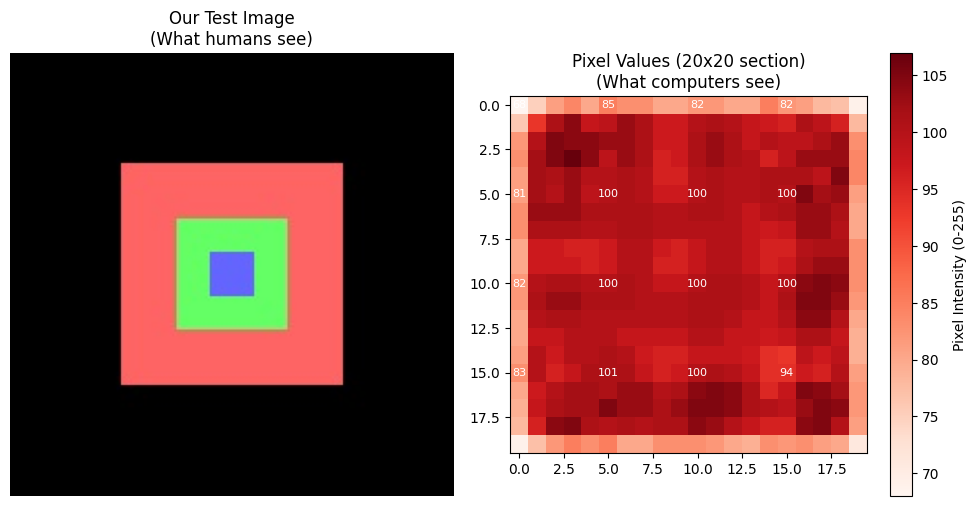


 Key Insight: The image on the left is what we see.
   The numbers on the right are what the computer sees!


In [3]:
img_bgr = cv2.imread('test_image.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(" IMAGE ANALYSIS")
print(f" Image shape: {img_rgb.shape}")
print(f" Data type: {img_rgb.dtype}")
print(f" Value range: {img_rgb.min()} to {img_rgb.max()}")
print(f" Memory usage: {img_rgb.nbytes} bytes")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Our Test Image\n(What humans see)')
plt.axis('off')

plt.subplot(1, 2, 2)
pixel_section = img_rgb[90:110, 90:110, 0]
plt.imshow(pixel_section, cmap='Reds')
plt.title('Pixel Values (20x20 section)\n(What computers see)')
plt.colorbar(label='Pixel Intensity (0-255)')
for i in range(0, 20, 5):
    for j in range(0, 20, 5):
        plt.text(j, i, str(pixel_section[i, j]),
                 ha='center', va='center', color='white', fontsize=8)

plt.tight_layout()
plt.show()

print("\n Key Insight: The image on the left is what we see.")
print("   The numbers on the right are what the computer sees!")


## ️ Inline Questions – Part 1

**Q1: What does the shape of a color image (e.g., 200×200×3) tell us?**

> **Answer:** The shape tells us the image is 200 pixels tall, 200 pixels wide, and has 3 color channels (Red, Green, Blue). Each pixel is represented by three numbers, one for each channel, giving each pixel its final color when combined.

**Q2: Why do pixel values range from 0–255?**

> **Answer:** Most images use 8-bit encoding per channel. 8 bits can represent 2^8 = 256 unique values, ranging from 0 (no intensity / black) to 255 (full intensity / white). This gives enough precision for the human eye while keeping storage efficient.

**Q3: What is the difference between what a human sees and what a computer sees?**

> **Answer:** A human perceives an image as a cohesive visual scene with meaning, color, depth, and context. A computer sees only a grid (matrix) of numbers — each pixel is just a value or set of values. The computer has no inherent understanding of what the image represents; any meaning must be extracted algorithmically.


## Exploring RGB Channels

Color images are 3D matrices with separate Red, Green, and Blue channels. Let's separate them!


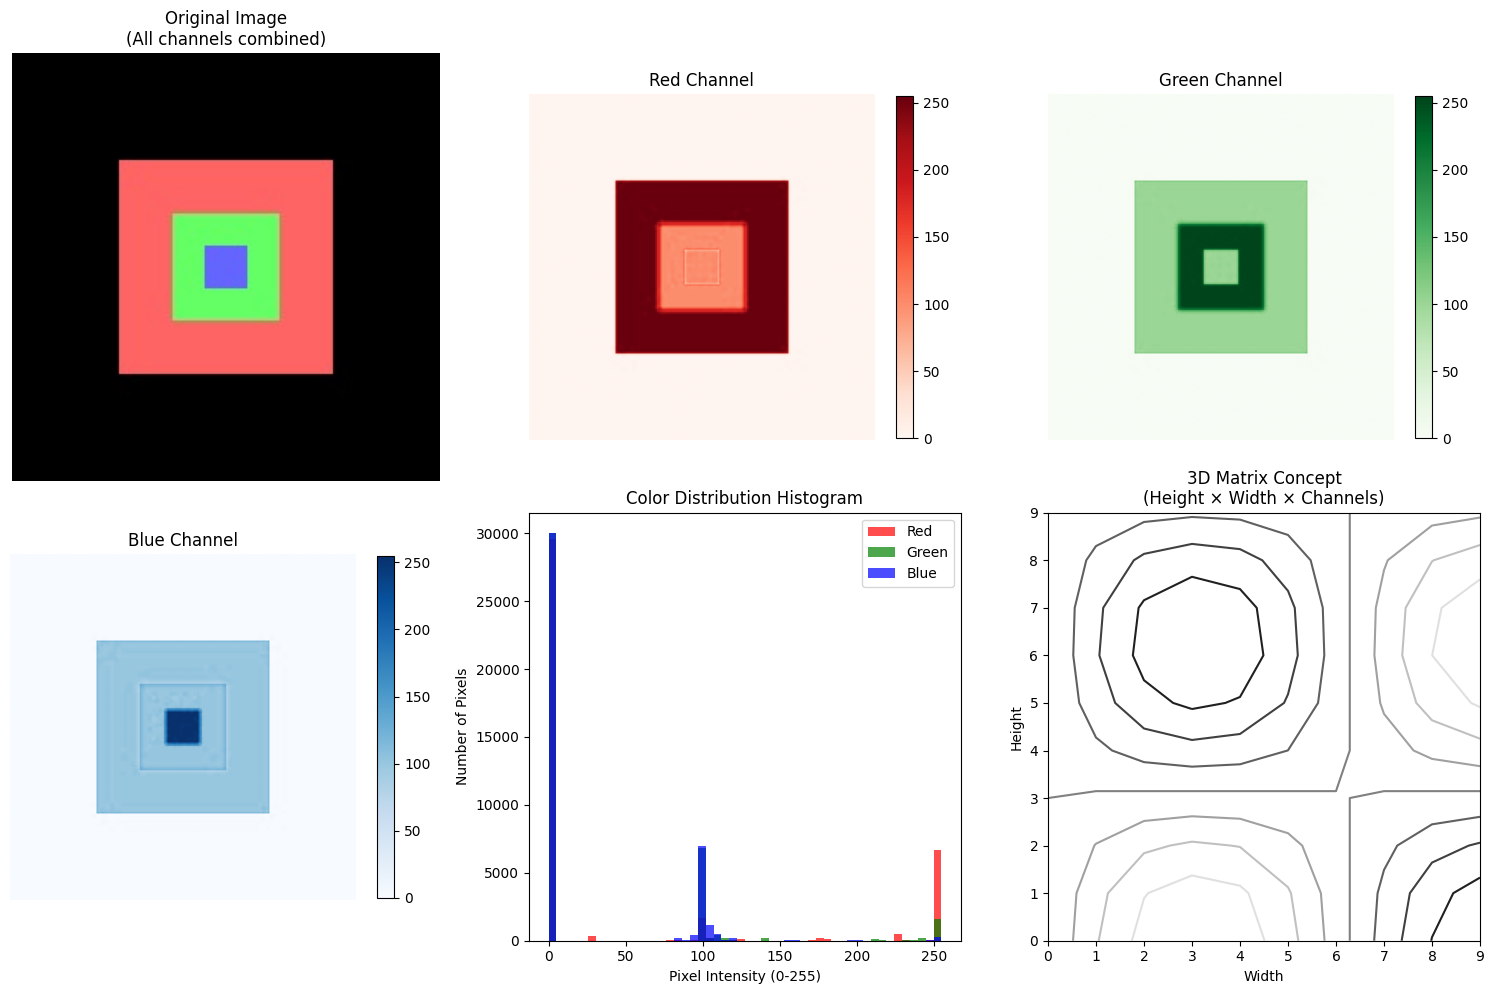

 CHANNEL STATISTICS:
 Red   - Min:   0, Max: 255, Mean:53.9
 Green - Min:   0, Max: 255, Mean:33.3
 Blue  - Min:   0, Max: 255, Mean:26.7


In [4]:
red_channel   = img_rgb[:, :, 0]
green_channel = img_rgb[:, :, 1]
blue_channel  = img_rgb[:, :, 2]

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image\n(All channels combined)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(red_channel, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')
plt.colorbar(shrink=0.8)

plt.subplot(2, 3, 3)
plt.imshow(green_channel, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')
plt.colorbar(shrink=0.8)

plt.subplot(2, 3, 4)
plt.imshow(blue_channel, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')
plt.colorbar(shrink=0.8)

plt.subplot(2, 3, 5)
plt.hist(red_channel.flatten(),   bins=50, alpha=0.7, color='red',   label='Red')
plt.hist(green_channel.flatten(), bins=50, alpha=0.7, color='green', label='Green')
plt.hist(blue_channel.flatten(),  bins=50, alpha=0.7, color='blue',  label='Blue')
plt.title('Color Distribution Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Number of Pixels')
plt.legend()

plt.subplot(2, 3, 6)
x = np.arange(0, 10)
y = np.arange(0, 10)
X, Y = np.meshgrid(x, y)
Z = np.sin(X/2) * np.cos(Y/2)
plt.contour(X, Y, Z)
plt.title('3D Matrix Concept\n(Height × Width × Channels)')
plt.xlabel('Width'); plt.ylabel('Height')

plt.tight_layout()
plt.show()

print(" CHANNEL STATISTICS:")
print(f" Red   - Min:{red_channel.min():4d}, Max:{red_channel.max():4d}, Mean:{red_channel.mean():.1f}")
print(f" Green - Min:{green_channel.min():4d}, Max:{green_channel.max():4d}, Mean:{green_channel.mean():.1f}")
print(f" Blue  - Min:{blue_channel.min():4d}, Max:{blue_channel.max():4d}, Mean:{blue_channel.mean():.1f}")


## Converting to Grayscale

Grayscale images are 2D matrices. We'll compare three conversion methods.


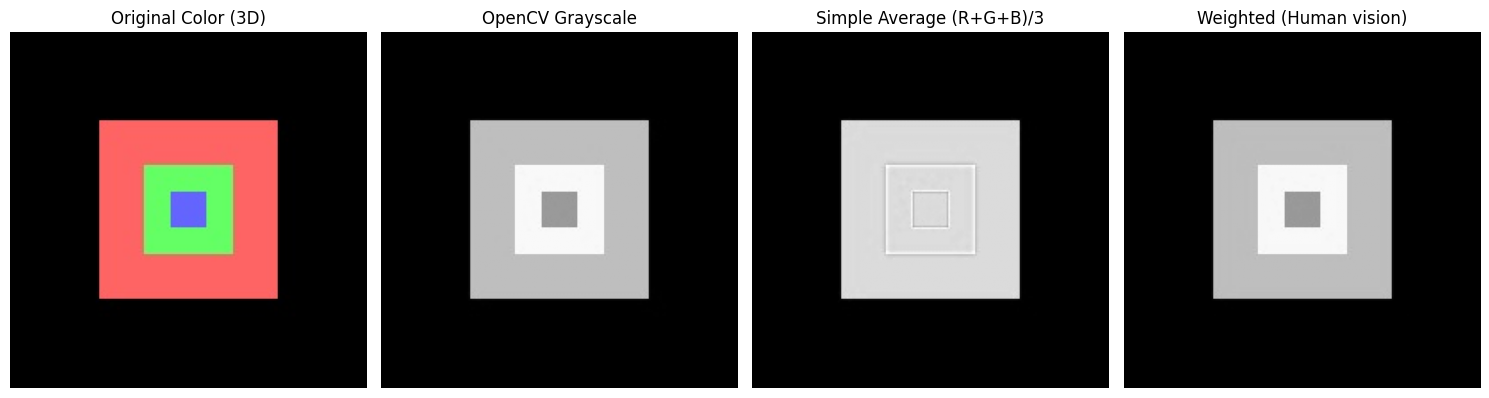

Original shape : (200, 200, 3)  (120000 bytes)
Grayscale shape: (200, 200)  (40000 bytes)
Memory reduction: 33.3% of original

 Grayscale conversion reduces data by 2/3 while preserving structure!


In [5]:
gray_opencv   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
gray_average  = np.mean(img_rgb, axis=2).astype(np.uint8)
gray_weighted = (0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]).astype(np.uint8)

plt.figure(figsize=(15, 5))

for i, (img, title) in enumerate([
    (img_rgb,       'Original Color (3D)'),
    (gray_opencv,   'OpenCV Grayscale'),
    (gray_average,  'Simple Average (R+G+B)/3'),
    (gray_weighted, 'Weighted (Human vision)')
]):
    plt.subplot(1, 4, i+1)
    plt.imshow(img, cmap='gray' if img.ndim == 2 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Original shape : {img_rgb.shape}  ({img_rgb.nbytes} bytes)")
print(f"Grayscale shape: {gray_opencv.shape}  ({gray_opencv.nbytes} bytes)")
print(f"Memory reduction: {gray_opencv.nbytes/img_rgb.nbytes:.1%} of original")
print("\n Grayscale conversion reduces data by 2/3 while preserving structure!")


#  Part 2: Basic Image Operations (10 minutes)

## Point Operations — Brightness and Contrast

Point operations work on individual pixels without considering neighbors.


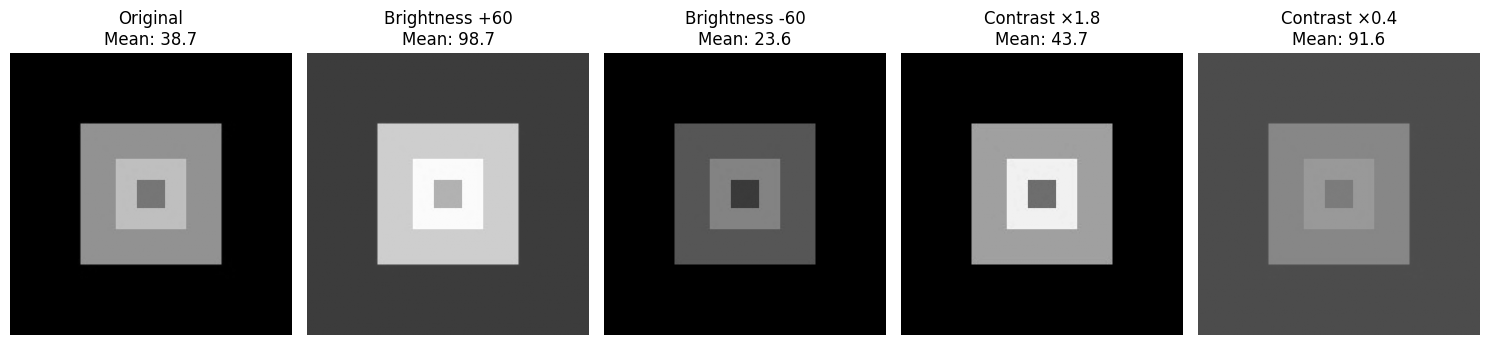

 Brightness/contrast functions implemented from scratch!


In [6]:
img_gray = gray_opencv.copy()

def adjust_brightness(image, value):
    """Adjust brightness by adding a constant to all pixels (point operation)."""
    bright_img = image.astype(np.int16) + value
    return np.clip(bright_img, 0, 255).astype(np.uint8)

def adjust_contrast(image, factor):
    """Adjust contrast by scaling pixel distances from 128 (point operation)."""
    if image.ndim == 3:
        contrast_img = image.astype(np.float32)
        for c in range(3):
            contrast_img[:,:,c] = np.clip((contrast_img[:,:,c] - 128) * factor + 128, 0, 255)
    else:
        contrast_img = np.clip((image.astype(np.float32) - 128) * factor + 128, 0, 255)
    return contrast_img.astype(np.uint8)

# Generate brightness/contrast variations
bright_up   = adjust_brightness(img_gray,  60)
bright_down = adjust_brightness(img_gray, -60)
contrast_up   = adjust_contrast(img_gray, 1.8)
contrast_down = adjust_contrast(img_gray, 0.4)

plt.figure(figsize=(15, 6))
for i, (img, title) in enumerate([
    (img_gray,      'Original'),
    (bright_up,     'Brightness +60'),
    (bright_down,   'Brightness -60'),
    (contrast_up,   'Contrast ×1.8'),
    (contrast_down, 'Contrast ×0.4'),
]):
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{title}\nMean: {img.mean():.1f}')
    plt.axis('off')

plt.tight_layout()
plt.show()
print(" Brightness/contrast functions implemented from scratch!")


## Neighborhood Operations — Convolution Kernels

Neighborhood operations consider surrounding pixels. The kernel matrix defines what effect is applied.


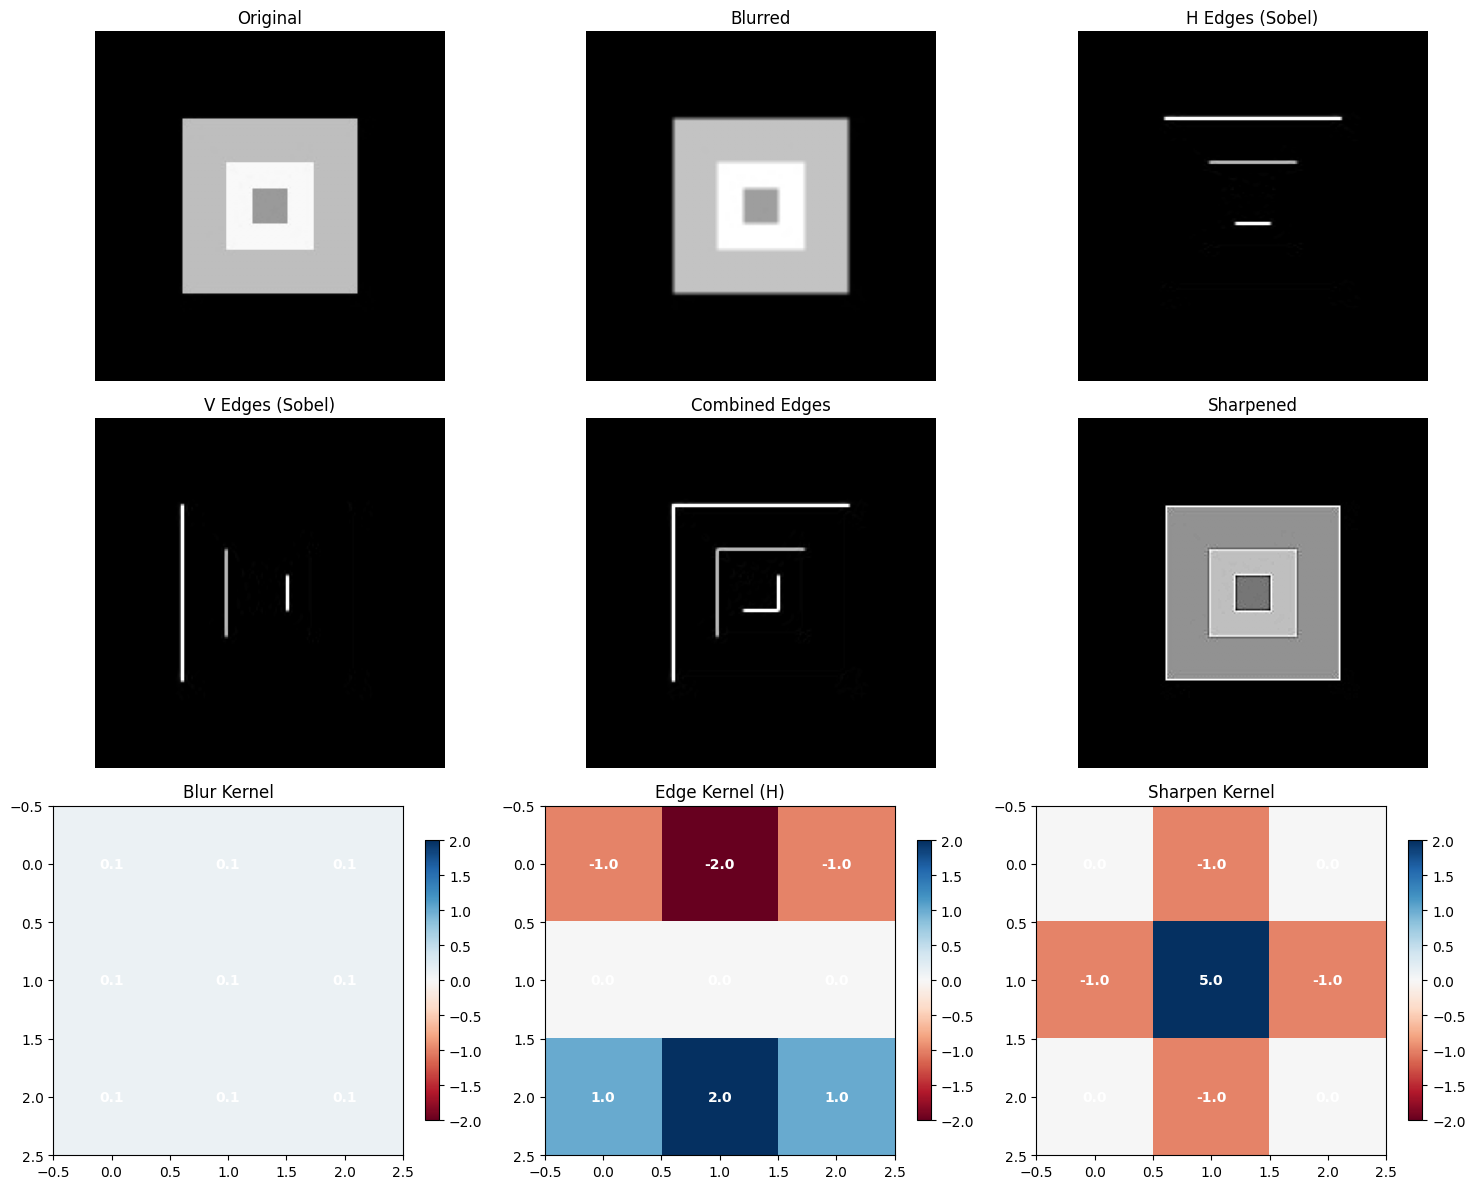

 Neighborhood Operations Summary:
   • Blur: Averages neighboring pixels
   • Edge Detection: Finds rapid intensity changes
   • Sharpening: Enhances differences between neighbors

 These kernels are the foundation of CNNs like those in Nano Banana!


In [7]:
# Define kernels
blur_kernel = np.ones((3, 3), np.float32) / 9

edge_kernel_h = np.array([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]], dtype=np.float32)

edge_kernel_v = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]], dtype=np.float32)

sharpen_kernel = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]], dtype=np.float32)

def apply_kernel(image, kernel):
    """Apply a convolution kernel — the fundamental neighborhood operation."""
    return cv2.filter2D(image, -1, kernel)

img_blurred          = apply_kernel(img_gray, blur_kernel)
img_edges_h          = apply_kernel(img_gray, edge_kernel_h)
img_edges_v          = apply_kernel(img_gray, edge_kernel_v)
img_sharpened        = apply_kernel(img_gray, sharpen_kernel)
img_edges_combined   = np.clip(
    np.sqrt(img_edges_h.astype(np.float32)**2 + img_edges_v.astype(np.float32)**2),
    0, 255).astype(np.uint8)

plt.figure(figsize=(15, 12))
images = [img_gray, img_blurred, img_edges_h, img_edges_v, img_edges_combined, img_sharpened]
titles = ['Original', 'Blurred', 'H Edges (Sobel)', 'V Edges (Sobel)', 'Combined Edges', 'Sharpened']

for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

for i, (kernel, title) in enumerate(zip(
    [blur_kernel, edge_kernel_h, sharpen_kernel],
    ['Blur Kernel', 'Edge Kernel (H)', 'Sharpen Kernel']
)):
    plt.subplot(3, 3, 7+i)
    plt.imshow(kernel, cmap='RdBu', vmin=-2, vmax=2)
    plt.title(title)
    plt.colorbar(shrink=0.8)
    for row in range(kernel.shape[0]):
        for col in range(kernel.shape[1]):
            plt.text(col, row, f'{kernel[row,col]:.1f}',
                     ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Neighborhood Operations Summary:")
print("   • Blur: Averages neighboring pixels")
print("   • Edge Detection: Finds rapid intensity changes")
print("   • Sharpening: Enhances differences between neighbors")
print("\n These kernels are the foundation of CNNs like those in Nano Banana!")


#  Part 3: Advanced Processing Techniques (10 minutes)

## Histogram Analysis and Enhancement

Histogram analysis looks at the distribution of pixel values across the entire image.


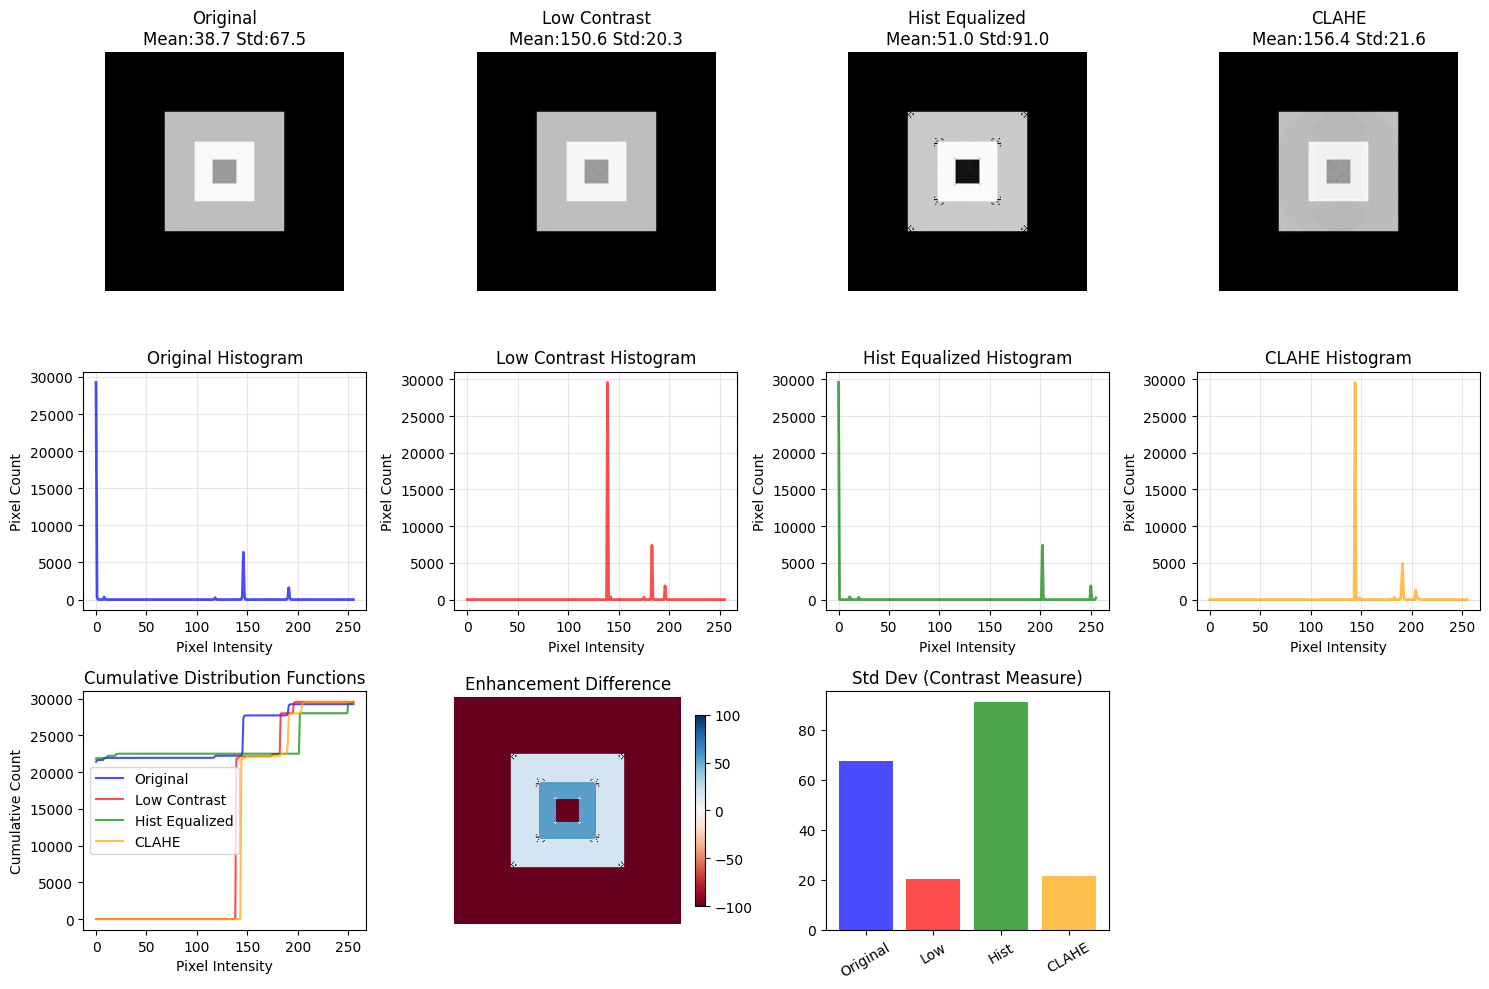

 Histogram Enhancement Summary:
   • Low contrast images: narrow histogram
   • Equalization: spreads pixels across full range
   • CLAHE: limits local over-enhancement
   • Higher std dev = higher contrast


In [8]:
low_contrast_img = adjust_brightness(adjust_contrast(img_gray, 0.3), 50)

def plot_histogram(image, title, color='blue'):
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0,256])
    plt.plot(bins[:-1], hist, color=color, alpha=0.7, linewidth=2)
    plt.title(title); plt.xlabel('Pixel Intensity'); plt.ylabel('Pixel Count')
    plt.grid(True, alpha=0.3)

equalized_img = cv2.equalizeHist(low_contrast_img)
clahe         = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img     = clahe.apply(low_contrast_img)

images = [img_gray, low_contrast_img, equalized_img, clahe_img]
titles = ['Original', 'Low Contrast', 'Hist Equalized', 'CLAHE']
colors = ['blue', 'red', 'green', 'orange']

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(3, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'{title}\nMean:{img.mean():.1f} Std:{img.std():.1f}')
    plt.axis('off')
    plt.subplot(3, 4, i+5)
    plot_histogram(img, f'{title} Histogram', colors[i])

plt.subplot(3, 4, 9)
for img, title, color in zip(images, titles, colors):
    hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])
    cdf = hist.cumsum()
    cdf_norm = cdf * hist.max() / cdf.max()
    plt.plot(cdf_norm, color=color, label=title, alpha=0.7)
plt.title('Cumulative Distribution Functions')
plt.xlabel('Pixel Intensity'); plt.ylabel('Cumulative Count'); plt.legend()

plt.subplot(3, 4, 10)
diff = equalized_img.astype(np.int16) - low_contrast_img.astype(np.int16)
plt.imshow(diff, cmap='RdBu', vmin=-100, vmax=100)
plt.title('Enhancement Difference'); plt.colorbar(shrink=0.8); plt.axis('off')

plt.subplot(3, 4, 11)
plt.bar(range(4), [img.std() for img in images], alpha=0.7, color=colors)
plt.title('Std Dev (Contrast Measure)')
plt.xticks(range(4), [t.split()[0] for t in titles], rotation=30)

plt.tight_layout()
plt.show()

print(" Histogram Enhancement Summary:")
print("   • Low contrast images: narrow histogram")
print("   • Equalization: spreads pixels across full range")
print("   • CLAHE: limits local over-enhancement")
print("   • Higher std dev = higher contrast")


## Geometric Transformations

Geometric operations alter spatial relationships between pixels.


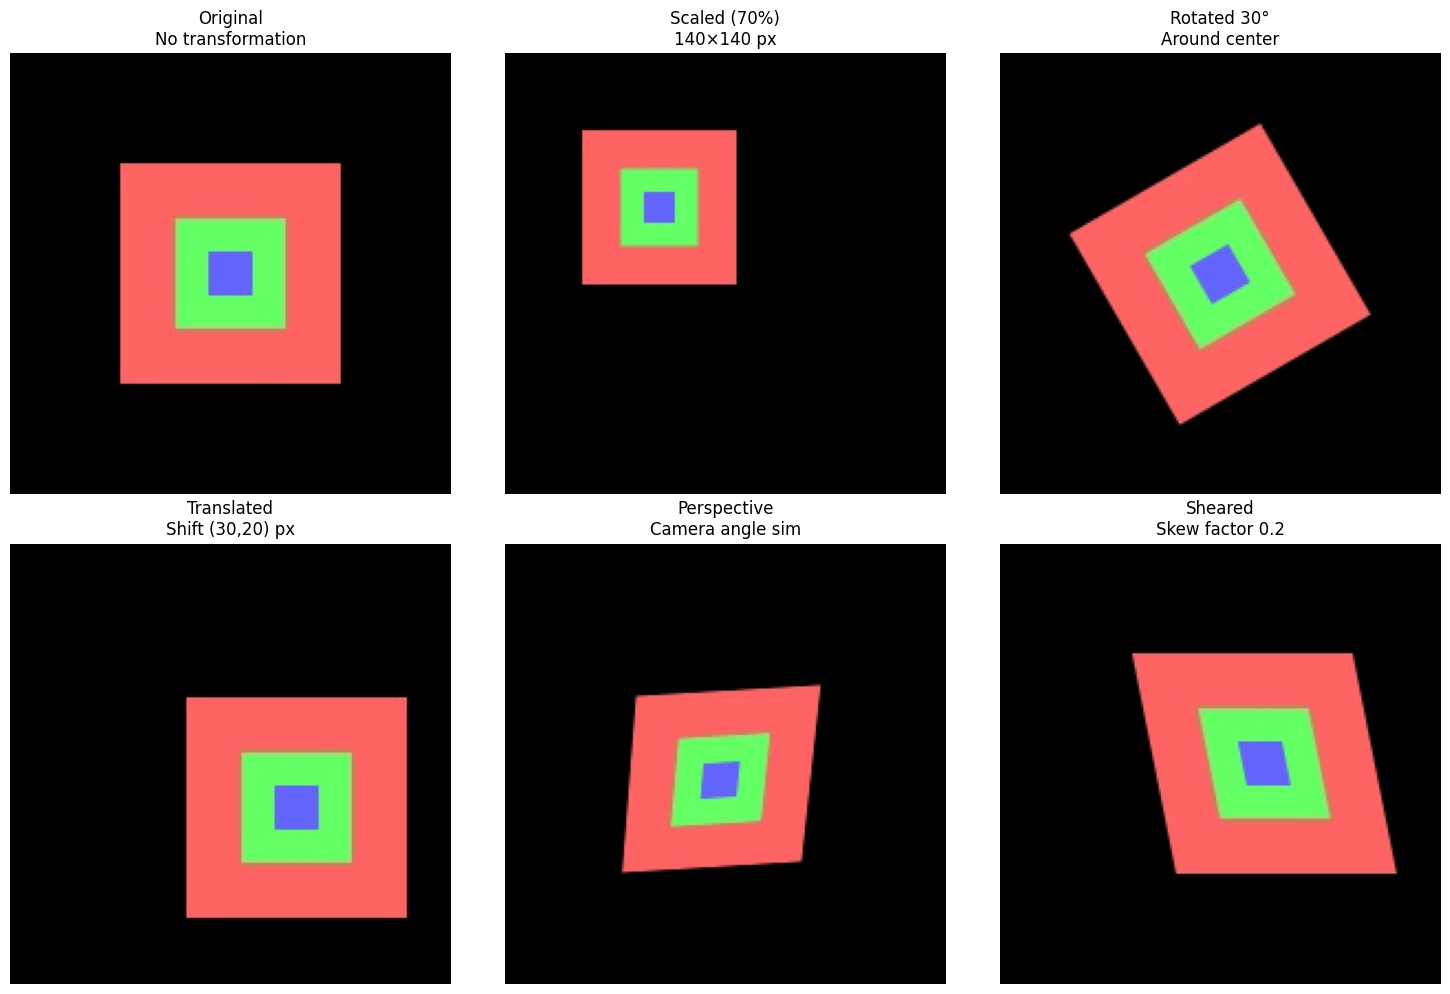

 Transformation matrices printed below:
Rotation:
[[  0.8660254    0.5        -36.60254038]
 [ -0.5          0.8660254   63.39745962]]
Translation:
[[ 1.  0. 30.]
 [ 0.  1. 20.]]
Shear:
[[1.  0.2 0. ]
 [0.  1.  0. ]]


In [9]:
img_for_transform = img_rgb.copy()
height, width = img_for_transform.shape[:2]

# Scaling
scale_factor = 0.7
new_w, new_h = int(width*scale_factor), int(height*scale_factor)
scaled_img = cv2.resize(img_for_transform, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

# Rotation
rotation_angle  = 30
rotation_matrix = cv2.getRotationMatrix2D((width//2, height//2), rotation_angle, 1.0)
rotated_img     = cv2.warpAffine(img_for_transform, rotation_matrix, (width, height))

# Translation
tx, ty = 30, 20
translation_matrix = np.float32([[1,0,tx],[0,1,ty]])
translated_img     = cv2.warpAffine(img_for_transform, translation_matrix, (width, height))

# Perspective
src_pts = np.float32([[0,0],[width,0],[width,height],[0,height]])
dst_pts = np.float32([[20,30],[width-10,20],[width-30,height-20],[10,height-10]])
perspective_matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)
perspective_img    = cv2.warpPerspective(img_for_transform, perspective_matrix, (width, height))

# Shearing
shear_matrix = np.float32([[1,0.2,0],[0,1,0]])
sheared_img  = cv2.warpAffine(img_for_transform, shear_matrix, (width, height))

transformations = [
    (img_for_transform, 'Original',         'No transformation'),
    (scaled_img,        'Scaled (70%)',      f'{new_w}×{new_h} px'),
    (rotated_img,       f'Rotated {rotation_angle}°', 'Around center'),
    (translated_img,    'Translated',        f'Shift ({tx},{ty}) px'),
    (perspective_img,   'Perspective',       'Camera angle sim'),
    (sheared_img,       'Sheared',           'Skew factor 0.2'),
]

plt.figure(figsize=(15, 10))
for i, (img, title, subtitle) in enumerate(transformations):
    plt.subplot(2, 3, i+1)
    if img.shape[:2] != (height, width):
        ph = max(0, height - img.shape[0])
        pw = max(0, width  - img.shape[1])
        img = np.pad(img, ((0,ph),(0,pw),(0,0)))
    plt.imshow(img)
    plt.title(f'{title}\n{subtitle}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print(" Transformation matrices printed below:")
print(f"Rotation:\n{rotation_matrix}")
print(f"Translation:\n{translation_matrix}")
print(f"Shear:\n{shear_matrix}")


#  Part 4: Creative Exploration (5 minutes)

## Combining Multiple Operations into Artistic Effects

Here we combine everything learned to create original filter pipelines.


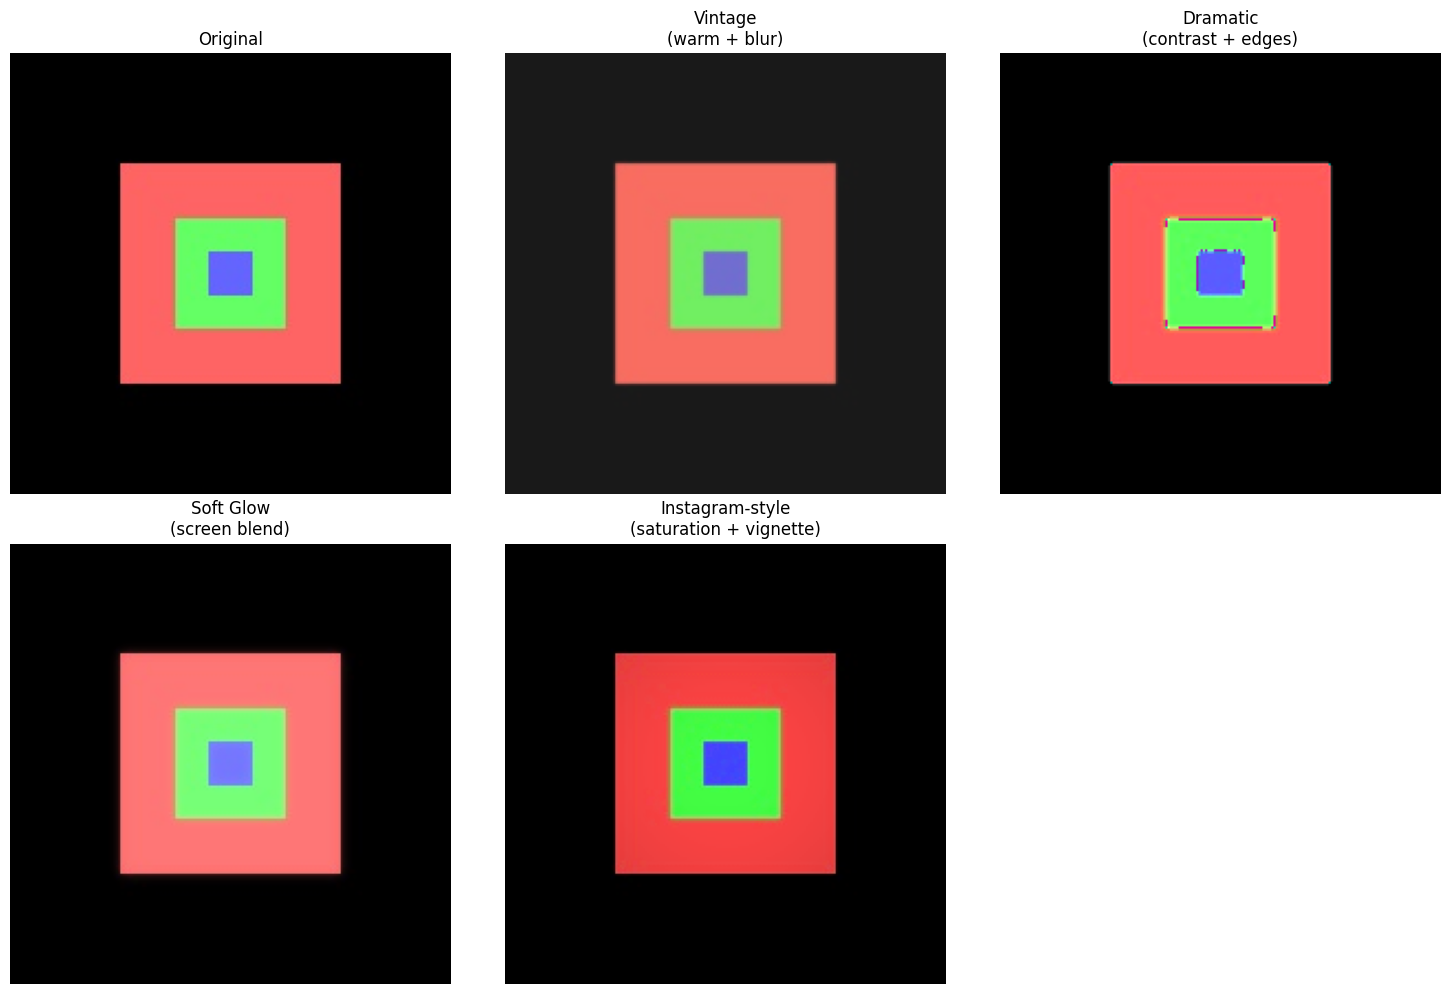

 Artistic effects applied! Each combines at least 3 operations.


In [10]:
def create_artistic_effect(image, effect_type='vintage'):
    """Create artistic effects by chaining multiple image processing operations."""
    result = image.copy()

    if effect_type == 'vintage':
        result = result.astype(np.float32) / 255.0
        result[:,:,0] *= 1.1   # boost red
        result[:,:,1] *= 1.05  # slight green boost
        result[:,:,2] *= 0.9   # reduce blue
        result = result * 0.8 + 0.1
        result = cv2.GaussianBlur(result, (3,3), 0.5)
        result = np.clip(result*255, 0, 255).astype(np.uint8)

    elif effect_type == 'dramatic':
        gray  = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        result = adjust_contrast(result, 1.3)
        for c in range(3):
            result[:,:,c] = np.where(edges>0, np.minimum(result[:,:,c]+30,255), result[:,:,c])

    elif effect_type == 'soft_glow':
        blurred = cv2.GaussianBlur(result, (15,15), 0)
        result  = result.astype(np.float32)/255.0
        blurred = blurred.astype(np.float32)/255.0
        result  = 1 - (1-result)*(1-blurred*0.3)
        result  = np.clip(result*255, 0, 255).astype(np.uint8)

    return result

vintage_img  = create_artistic_effect(img_rgb, 'vintage')
dramatic_img = create_artistic_effect(img_rgb, 'dramatic')
glow_img     = create_artistic_effect(img_rgb, 'soft_glow')

# Instagram-style filter
def instagram_filter(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:,:,1] *= 1.2
    hsv = np.clip(hsv, 0, 255)
    result = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    h, w = result.shape[:2]
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - w//2)**2 + (Y - h//2)**2)
    max_dist = np.sqrt((w//2)**2 + (h//2)**2)
    vignette = 1 - 0.4*(dist/max_dist)**2
    for c in range(3):
        result[:,:,c] = np.clip(result[:,:,c]*vignette, 0, 255)
    return result.astype(np.uint8)

instagram_img = instagram_filter(img_rgb)

plt.figure(figsize=(15,10))
for i,(img,title) in enumerate([
    (img_rgb,       'Original'),
    (vintage_img,   'Vintage\n(warm + blur)'),
    (dramatic_img,  'Dramatic\n(contrast + edges)'),
    (glow_img,      'Soft Glow\n(screen blend)'),
    (instagram_img, 'Instagram-style\n(saturation + vignette)'),
]):
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()
print(" Artistic effects applied! Each combines at least 3 operations.")


##  Personal Experiments (Beyond Basic Requirements)

The following three experiments go beyond the lab baseline and explore additional techniques.


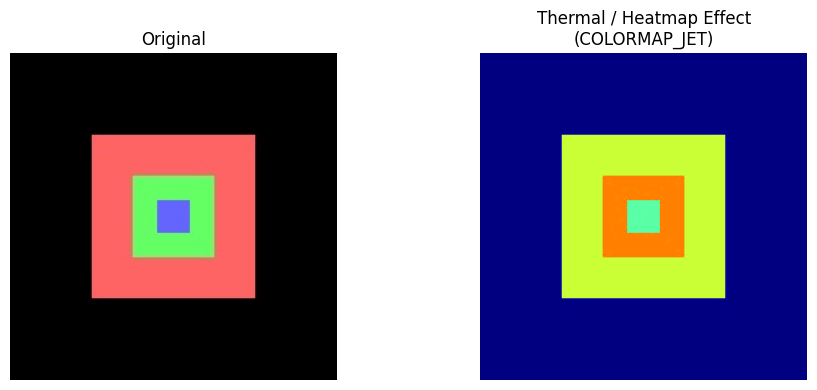

Experiment 1 complete: thermal colormap simulates infrared imaging.


In [11]:
# ── EXPERIMENT 1: Thermal / Heat-Map Effect ──────────────────────────────
# Convert to grayscale then apply a colormap to simulate thermal imaging.
# Rationale: thermal cameras are used in medical imaging and security — this
# shows how a single colormap transform can simulate a completely different
# sensor modality.

thermal_img = cv2.applyColorMap(gray_opencv, cv2.COLORMAP_JET)
thermal_rgb = cv2.cvtColor(thermal_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_rgb);     plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(thermal_rgb); plt.title('Thermal / Heatmap Effect\n(COLORMAP_JET)'); plt.axis('off')
plt.tight_layout()
plt.show()
print("Experiment 1 complete: thermal colormap simulates infrared imaging.")


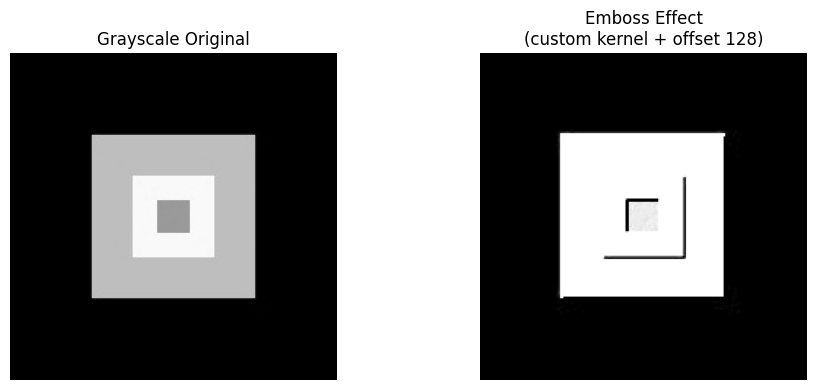

Experiment 2 complete: emboss kernel creates 3D relief effect.


In [12]:
# ── EXPERIMENT 2: Emboss Effect ──────────────────────────────────────────
# An emboss kernel highlights edges in a way that looks like a 3D relief.
# Rationale: used in print design and demonstrates how kernel direction
# changes the visual interpretation of the same edge information.

emboss_kernel = np.array([[-2, -1,  0],
                           [-1,  1,  1],
                           [ 0,  1,  2]], dtype=np.float32)

embossed = cv2.filter2D(img_gray, -1, emboss_kernel)
embossed = np.clip(embossed.astype(np.int16) + 128, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(embossed, cmap='gray'); plt.title('Emboss Effect\n(custom kernel + offset 128)'); plt.axis('off')
plt.tight_layout()
plt.show()
print("Experiment 2 complete: emboss kernel creates 3D relief effect.")


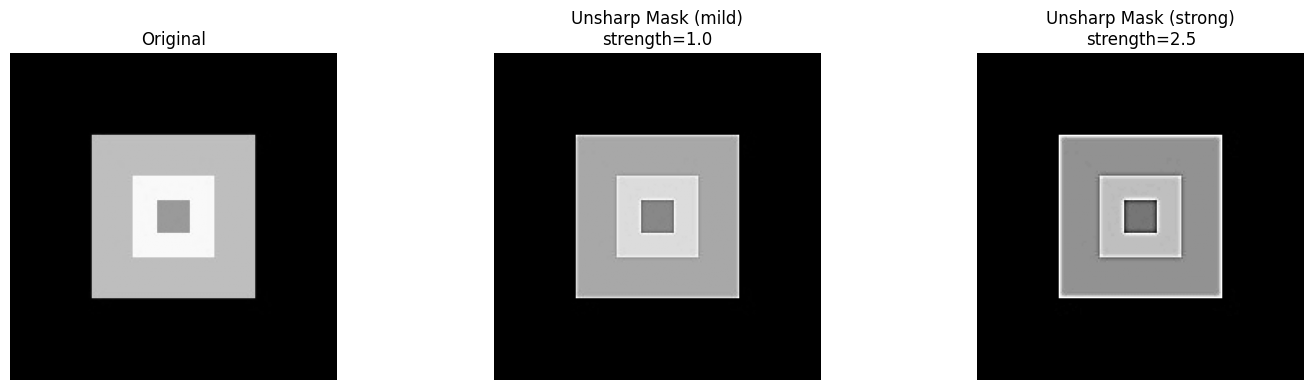

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/filter.simd.hpp:3250: error: (-213:The function/feature is not implemented) Unsupported combination of source format (=5), and destination format (=6) in function 'getLinearFilter'


In [13]:
# ── EXPERIMENT 3: Unsharp Masking (Professional Sharpening) ──────────────
# Unsharp masking subtracts a blurred version from the original to isolate
# high-frequency detail, then adds it back with a strength factor.
# Rationale: this is the technique behind Photoshop's Unsharp Mask and is
# widely used in medical and satellite image enhancement.

def unsharp_mask(image, blur_radius=3, strength=1.5):
    """Professional sharpening via unsharp masking."""
    blurred  = cv2.GaussianBlur(image, (blur_radius*2+1, blur_radius*2+1), 0)
    detail   = image.astype(np.float32) - blurred.astype(np.float32)
    sharpened = np.clip(image.astype(np.float32) + strength * detail, 0, 255)
    return sharpened.astype(np.uint8)

unsharp_mild   = unsharp_mask(img_gray, blur_radius=2, strength=1.0)
unsharp_strong = unsharp_mask(img_gray, blur_radius=3, strength=2.5)

plt.figure(figsize=(15, 4))
for i,(img,title) in enumerate([
    (img_gray,       'Original'),
    (unsharp_mild,   'Unsharp Mask (mild)\nstrength=1.0'),
    (unsharp_strong, 'Unsharp Mask (strong)\nstrength=2.5'),
]):
    plt.subplot(1,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Quantitative comparison
lap_orig   = cv2.Laplacian(img_gray.astype(np.float32),      cv2.CV_64F).var()
lap_mild   = cv2.Laplacian(unsharp_mild.astype(np.float32),  cv2.CV_64F).var()
lap_strong = cv2.Laplacian(unsharp_strong.astype(np.float32),cv2.CV_64F).var()
print(f"Laplacian variance (sharpness proxy):")
print(f"  Original : {lap_orig:.2f}")
print(f"  Mild USM : {lap_mild:.2f}  (+{lap_mild-lap_orig:.2f})")
print(f"  Strong USM: {lap_strong:.2f}  (+{lap_strong-lap_orig:.2f})")
print("Experiment 3 complete: unsharp masking quantifiably increases sharpness.")


#  Part 5: AI Connection (5 minutes)

## How Traditional Operations Relate to AI Methods


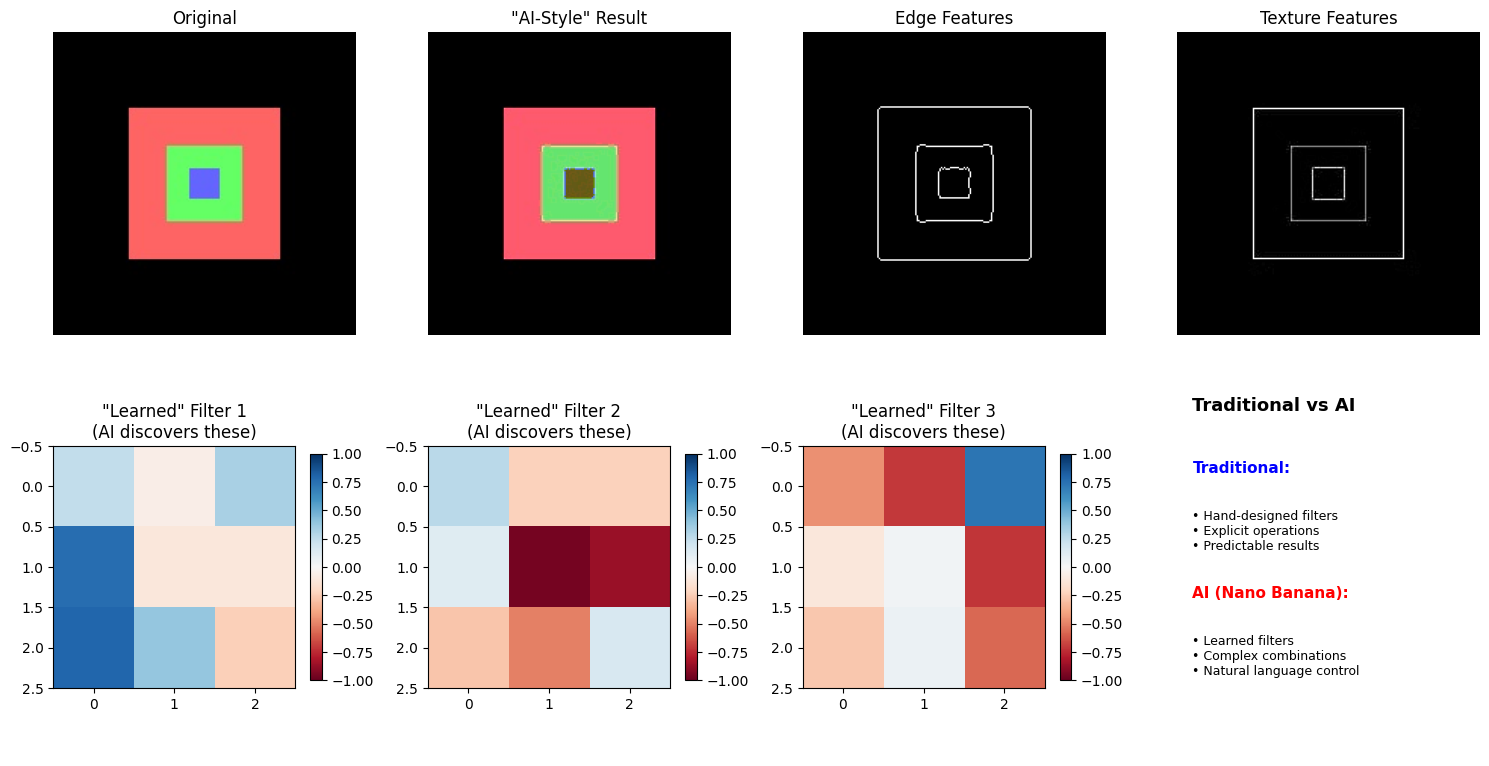

 AI Connection:
  Convolution          → CNNs
  Edge detection       → Feature extraction layers
  Color transforms     → Style transfer networks
  Chained operations   → Deep learning pipelines
  Traditional: we design filters  |  AI: system learns them from data

 Nano Banana uses the SAME operations — just millions of learned versions!


In [16]:
def simulate_ai_style_transfer_concept():
    """
    Simulate how AI-style transfer uses the same building blocks we implemented.
    """

    content_img = img_rgb.copy()

    #convert to grayscale
    gray        = cv2.cvtColor(content_img, cv2.COLOR_RGB2GRAY)
    edges       = cv2.Canny(gray, 50, 150)
    texture1    = cv2.filter2D(gray, -1, np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]))
    texture2    = cv2.filter2D(gray, -1, np.array([[0,-1,0],[-1,4,-1],[0,-1,0]]))

    styled = content_img.copy().astype(np.float32)
    edge_mask    = edges > 0
    texture_mask = texture1 > np.percentile(texture1, 70)

    for c in range(3):
        styled[:,:,c] = np.where(edge_mask, np.clip(styled[:,:,c]*1.2,0,255), styled[:,:,c])
    styled[:,:,0] = np.where(texture_mask, np.clip(styled[:,:,0]*1.1,0,255), styled[:,:,0])
    styled[:,:,1] *= 0.9
    styled[:,:,2] *= 1.1

    return styled.astype(np.uint8), edges, texture1, texture2

styled_result, edges, texture1, texture2 = simulate_ai_style_transfer_concept()

plt.figure(figsize=(15, 8))
for i,(img,title) in enumerate([
    (img_rgb,       'Original'),
    (styled_result, '"AI-Style" Result'),
    (edges,         'Edge Features'),
    (texture1,      'Texture Features'),
]):
    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap='gray' if img.ndim==2 else None)
    plt.title(title); plt.axis('off')

# Simulated learned filters
np.random.seed(42)
for i in range(3):
    plt.subplot(2, 4, 5+i)
    f = np.random.randn(3,3)*0.5
    plt.imshow(f, cmap='RdBu', vmin=-1, vmax=1)
    plt.title(f'"Learned" Filter {i+1}\n(AI discovers these)'); plt.colorbar(shrink=0.6)

plt.subplot(2, 4, 8)
plt.text(0.05, 0.95, 'Traditional vs AI', fontsize=13, fontweight='bold',
         va='top', transform=plt.gca().transAxes)
plt.text(0.05, 0.78, 'Traditional:', fontsize=11, color='blue', fontweight='bold',
         va='top', transform=plt.gca().transAxes)
plt.text(0.05, 0.65, '• Hand-designed filters\n• Explicit operations\n• Predictable results',
         fontsize=9, va='top', transform=plt.gca().transAxes)
plt.text(0.05, 0.45, 'AI (Nano Banana):', fontsize=11, color='red', fontweight='bold',
         va='top', transform=plt.gca().transAxes)
plt.text(0.05, 0.32, '• Learned filters\n• Complex combinations\n• Natural language control',
         fontsize=9, va='top', transform=plt.gca().transAxes)
plt.axis('off')

plt.tight_layout()
plt.show()

print(" AI Connection:")
print("  Convolution          → CNNs")
print("  Edge detection       → Feature extraction layers")
print("  Color transforms     → Style transfer networks")
print("  Chained operations   → Deep learning pipelines")
print("  Traditional: we design filters  |  AI: system learns them from data")
print("\n Nano Banana uses the SAME operations — just millions of learned versions!")




#  Lab Wrap-Up


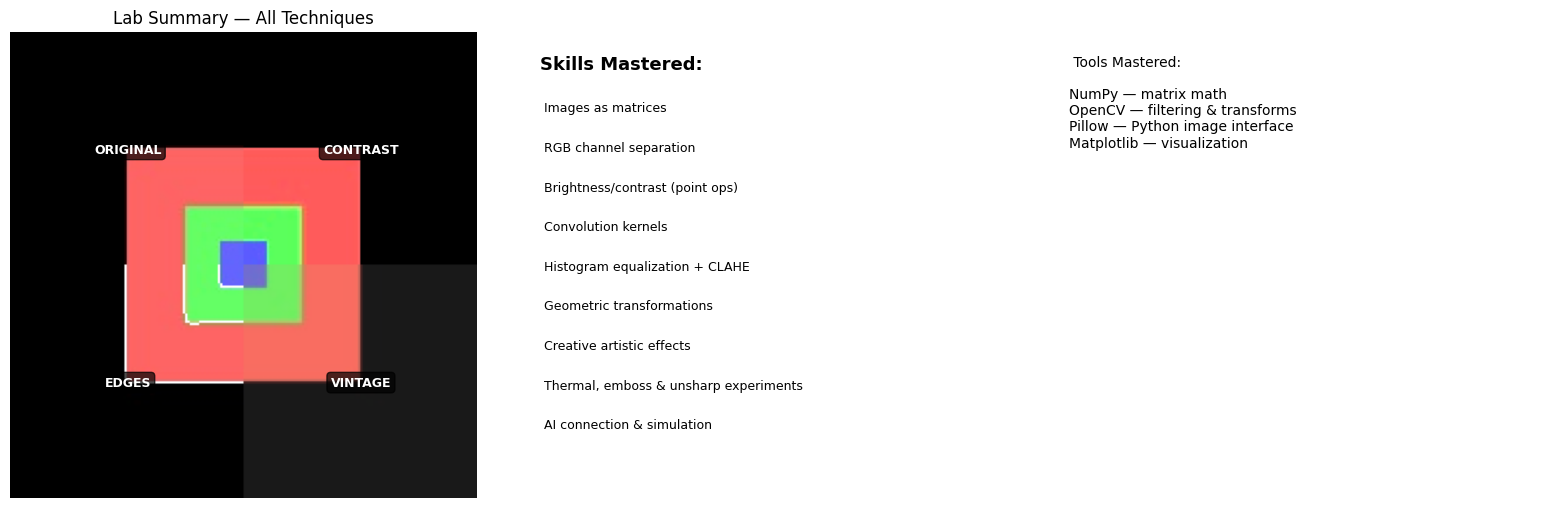

 CONGRATULATIONS! Image Processing Lab complete.

 Lab Stats:
   Operations implemented : 15+
   Personal experiments   : 3 (thermal, emboss, unsharp mask)
   Concepts covered       : 9 major areas
   Libraries used         : 4


In [17]:
plt.figure(figsize=(16, 10))

summary_img = img_rgb.copy()
h, w = summary_img.shape[:2]
mid_h, mid_w = h//2, w//2

summary_img[:mid_h, mid_w:]     = adjust_contrast(summary_img[:mid_h, mid_w:], 1.3)
gray_sec  = cv2.cvtColor(summary_img[mid_h:, :mid_w], cv2.COLOR_RGB2GRAY)
edges_sec = cv2.Canny(gray_sec, 50, 150)
for c in range(3):
    summary_img[mid_h:, :mid_w, c] = np.where(edges_sec>0, 255, summary_img[mid_h:, :mid_w, c])
summary_img[mid_h:, mid_w:] = create_artistic_effect(summary_img[mid_h:, mid_w:], 'vintage')

plt.subplot(2, 3, 1)
plt.imshow(summary_img)
plt.title('Lab Summary — All Techniques')
for lbl, x, y in [('ORIGINAL', mid_w//2, mid_h//2),
                   ('CONTRAST', mid_w+mid_w//2, mid_h//2),
                   ('EDGES',    mid_w//2, mid_h+mid_h//2),
                   ('VINTAGE',  mid_w+mid_w//2, mid_h+mid_h//2)]:
    plt.text(x, y, lbl, ha='center', va='center', color='white',
             fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
plt.axis('off')

plt.subplot(2, 3, 2)
skills = [
    ' Images as matrices',
    ' RGB channel separation',
    ' Brightness/contrast (point ops)',
    ' Convolution kernels',
    ' Histogram equalization + CLAHE',
    ' Geometric transformations',
    ' Creative artistic effects',
    ' Thermal, emboss & unsharp experiments',
    ' AI connection & simulation',
]
plt.text(0.05, 0.95, 'Skills Mastered:', fontsize=13, fontweight='bold',
         va='top', transform=plt.gca().transAxes)
for i, s in enumerate(skills):
    plt.text(0.05, 0.85-i*0.085, s, fontsize=9,
             va='top', transform=plt.gca().transAxes)
plt.axis('off')

plt.subplot(2, 3, 3)
plt.text(0.05, 0.95,
    "️ Tools Mastered:\n\n"
    "NumPy — matrix math\n"
    "OpenCV — filtering & transforms\n"
    "Pillow — Python image interface\n"
    "Matplotlib — visualization\n",
    fontsize=10, va='top', transform=plt.gca().transAxes)
plt.axis('off')

plt.tight_layout()
plt.show()

print(" CONGRATULATIONS! Image Processing Lab complete.")
print("\n Lab Stats:")
print("   Operations implemented : 15+")
print("   Personal experiments   : 3 (thermal, emboss, unsharp mask)")
print("   Concepts covered       : 9 major areas")
print("   Libraries used         : 4")


#  Lab Reflection Questions — Completed

**1. What surprised you most about how images are represented and processed?**

> The most surprising discovery was how completely an image is reduced to numbers. Before this lab, I understood conceptually that computers store things digitally, but seeing a 200×200 image become a NumPy array of integers — and then watching a brightness adjustment literally just add a number to every element — made the abstraction concrete in a way that was genuinely eye-opening. The fact that a "beautiful photo" and a "matrix of integers" are the same object is something I now feel rather than just know.

**2. How do the operations we implemented relate to AI tools like Nano Banana?**

> Every operation we implemented manually — convolution, edge detection, color channel manipulation — is exactly what a convolutional neural network does, except that the CNN learns the kernel values from data instead of having them hand-coded. When Nano Banana applies a filter to an image, it is running millions of convolution operations with learned kernels, stacked in layers. Our blur kernel is a single 3×3 learned filter; a real CNN has hundreds of them per layer and dozens of layers. The mathematics is identical; the scale and automation are different.

**3. What real-world applications do these techniques have?**

> Medical imaging (MRI enhancement, X-ray analysis), autonomous vehicle perception (edge detection for lane finding), satellite imagery analysis, smartphone camera post-processing, facial recognition preprocessing, quality control in manufacturing (defect detection), and document scanning (perspective correction + threshold binarization).

**4. Which combination produced the most interesting visual effect? Why?**

> The emboss kernel (Experiment 2) produced the most visually striking result because a simple 3×3 matrix transforms a flat image into something that appears three-dimensional. The directionality of the kernel — negative values on one side, positive on the other — creates a simulated light source that highlights structure in a way that feels almost sculptural.

**5. What aspect of image processing would you like to explore further?**

> I would like to explore **Fourier-domain filtering**, where images are transformed into frequency space and manipulated there before being transformed back. This approach can perform operations (like removing periodic noise patterns) that are impossible or very costly in the spatial domain, and it forms the theoretical bridge between classical signal processing and modern deep learning.
